In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [29]:
def readImages(folder, num_images):
    arr_images = []
    for i in range(num_images):
        arr_images.append(cv2.imread(f'{folder}{i}.jpg'))
    return np.array(arr_images, dtype=np.uint8)

def images_to_gray(images: np.array):
    result = []
    
    for i in range(len(images)):
        result.append(cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY))
    
    return result

folder = '../images/'
im = readImages(folder, 2)

NameError: name 'width' is not defined

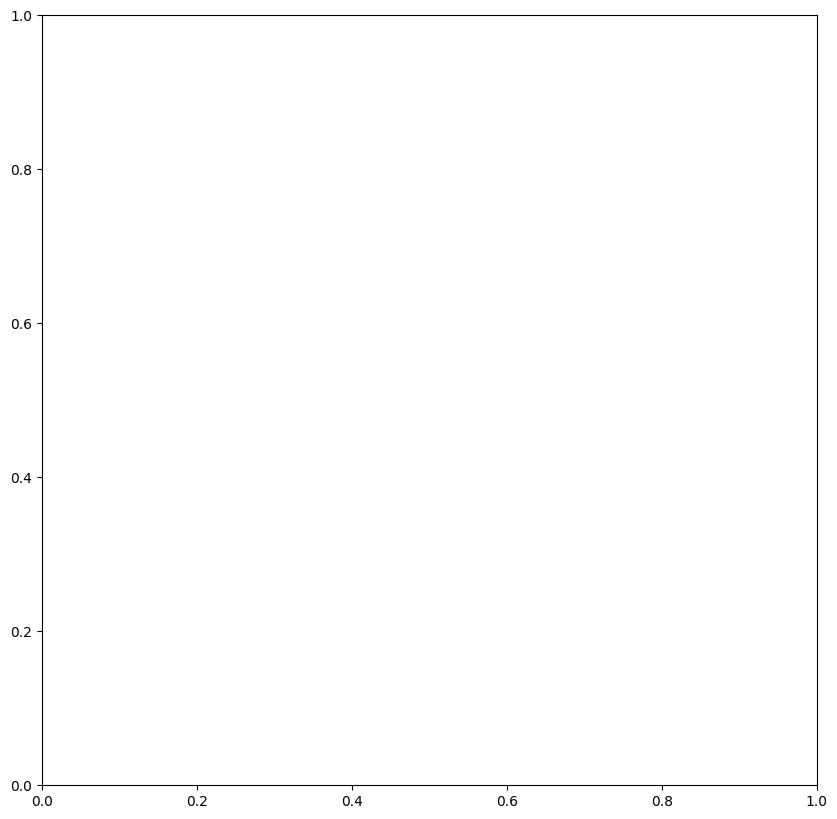

In [30]:
def project_images_onto_plane(img1, img2):


    # Detect keypoints
    sift = cv2.SIFT_create()
    keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
    keypoints2, descriptors2 = sift.detectAndCompute(img2, None)
    
    
    # Match Descriptors
    index_params = dict(algorithm=1, trees=5)
    search_params = dict(checks=50)
    matcher = cv2.FlannBasedMatcher(index_params, search_params)
    matches = matcher.knnMatch(descriptors1, descriptors2, k=2)
    
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)
            
            
    if len(good_matches) > 4:
        src_pts = []
        tgt_pts = []
        
        for match in good_matches:
            kp1 = keypoints1[match.queryIdx].pt
            src_pts.append(kp1)
            
            kp2 = keypoints2[match.trainIdx].pt
            tgt_pts.append(kp2)
            
        src_pts = np.float32(src_pts)
        tgt_pts = np.float32(tgt_pts)
        
        threshold = 5
        H, inliers = cv2.findHomography(
            src_pts,
            tgt_pts,
            cv2.RANSAC,
            threshold
        )
        
        # h1, w1 = img_top.shape[:2]
        # h2, w2 = img_bottom.shape[:2]
        
        warped = cv2.warpPerspective(
            img1,
            H,
            (width, height)
        )
        
        return warped
    else:
        print("Not enough matches are found - %d/%d" % (len(good_matches), 5))
        return None

folder = '../images/'
images = readImages(folder, 2)
images_gray = images_to_gray(images)

fig, ax = plt.subplots(figsize=(10, 10))

# print(images_gray[0])

warped = project_images_onto_plane(images_gray[1], images_gray[0])
ax.imshow(warped)
plt.show()

# Okay, i think this works

### Contour Detection

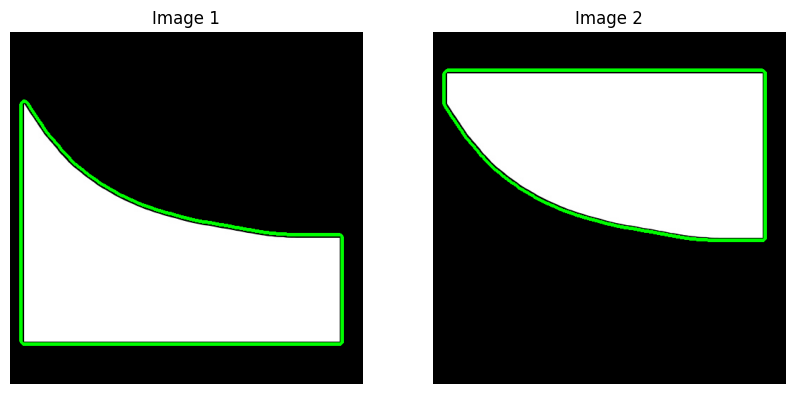

In [196]:
def contourExtraction(image):
    # First, apply gaussian blur
    image_blur = cv2.GaussianBlur(image, (9,9), 0)
    
    # Now, we will threshold to ignore text from images
    
    _, thres = cv2.threshold(
        image_blur,
        1,
        255,
        cv2.THRESH_BINARY_INV
    )
    # Edge detection
    t_lower = 50
    t_upper = 150
    edges = cv2.Canny(thres, t_lower, t_upper)
    
    # Then, find contours
    contours, hierarchy = cv2.findContours(edges,
                                           cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    approxDP = []
    for contour in contours:
        epsilon = 0.2
        approx = cv2.approxPolyDP(contour, epsilon, True)
        approxDP.append(approx)
    # Lastly, we obtain the 
    return approxDP

folder = '../test_images/'
images = readImages(folder, 6)
images_gray = images_to_gray(images)

image1 = images_gray[4]
image2 = images_gray[5]
contours1 = contourExtraction(image1)
contours2 = contourExtraction(image2)

#inners1 = [extract_inner_segment(contour) for contour in contours1]
#inners2 = [extract_inner_segment(contour) for contour in contours2]
inners1 = contours1
inners2 = contours2

output1 = cv2.cvtColor(image1, cv2.COLOR_GRAY2BGR)
cv2.drawContours(
    output1,
    inners1,
    -1, (0, 255, 0), 3
)

output2 = cv2.cvtColor(image2, cv2.COLOR_GRAY2BGR)
cv2.drawContours(
    output2,
    inners2,
    -1, (0, 255, 0), 3
)


fig, ax = plt.subplots(1,2, figsize=(10, 10))
ax[0].imshow(cv2.cvtColor(output1, cv2.COLOR_BGR2RGB))
ax[0].set_title("Image 1")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(output2, cv2.COLOR_BGR2RGB))
ax[1].set_title("Image 2")
ax[1].axis("off")
plt.show()

### Contour Matching using ICP

In [197]:

import numpy as np
from sklearn.neighbors import NearestNeighbors

def cleanContours(contours):
    return [pts[:,0,:] for pts in contours]
    

def best_fit_transform(A, B):
    

    centroid_A = np.mean(A, axis=0)
    centroid_B = np.mean(B, axis=0)
    
    AA = A - centroid_A
    BB = B - centroid_B
    
    H = np.dot(AA.T, BB)
    U, S, Vt = np.linalg.svd(H)
    
    R = np.dot(Vt.T, U.T)
    
    if np.linalg.det(R) < 0:
       Vt[-1,:] *= -1
       R = np.dot(Vt.T, U.T)
    
    scale = 1
    
    t = centroid_B.reshape(-1,1) - scale * np.dot(R, centroid_A.reshape(-1,1))
    
    print(R)
    print(t)
    
    T = np.eye(3)
    
    T[:2,:2] = scale * R
    T[:2, 2] = t.T
    
    return T

def nearest_neighbor(src, dst):
    # Ensure shapes are compatible for KNN, although they don't strictly need to be identical N
    assert src.shape[1] == dst.shape[1]
    neigh = NearestNeighbors(n_neighbors=1)
    neigh.fit(dst)
    distances, indices = neigh.kneighbors(src, return_distance=True)
    return distances.ravel(), indices.ravel()

def icp(A, B, max_iterations=20, tolerance=0.001):
    '''
    The Iterative Closest Point method: finds best-fit transform that maps points A on to points B.
    Stores intermediate results for visualization.
    Input:
        A: Nxm numpy array of source points
        B: Nxm numpy array of destination points
        max_iterations: exit algorithm after max_iterations
        tolerance: convergence criteria
    Output:
        T_final: final homogeneous transformation that maps A on to B
        intermediate_A: List containing A transformed at each iteration (N x m arrays)
        intermediate_errors: List containing the mean error at each iteration
        i: number of iterations to converge
    '''
 
    # Check dimensions
    # Allow N to differ, but dimensions (m) must match
    assert A.shape[1] == B.shape[1]
 
    # get number of dimensions
    m = A.shape[1]
     
    # --- Store History ---
    intermediate_A = [np.copy(A)] # Store initial state
    intermediate_errors = []
    # --- Store History ---
 
    # make points homogeneous, copy them to maintain the originals
    # Use np.copy() for src to allow modification without affecting original A
    src_h = np.vstack([
        A.T,
        np.ones((1, A.shape[0]))
    ])
     
    # Target points (B) remain fixed, use non-homogeneous for KNN
    dst = np.copy(B) # Non-homogeneous target points for KNN
 
    prev_error = float('inf') # Initialize with infinity
    T_cumulative = np.identity(m+1) # To accumulate transformations correctly
 
    for i in range(max_iterations):
        # Current source points (non-homogeneous)
        current_src = src_h[:m, :].T
 
        # find the nearest neighbors between the current source and destination points
        distances, indices = nearest_neighbor(current_src, dst)
 
        # compute the transformation between the current source and nearest destination points
        # Use the subset of B (dst) corresponding to the nearest neighbors found
        T_step = best_fit_transform(current_src, dst[indices, :])
 
        # update the current source points *in homogeneous coordinates*
        src_h = np.dot(T_step, src_h)
         
        # --- Store History ---
        intermediate_A.append(src_h[:m, :].T) # Store transformed A for this iteration
        # --- Store History ---
 
        # check error (stop if error is less than specified tolerance)
        mean_error = np.mean(distances)
        intermediate_errors.append(mean_error) # Store error for this iteration
         
        # Use absolute difference check for convergence
        if np.abs(prev_error - mean_error) < tolerance:
            print(f"Converged at iteration {i+1} with error difference {np.abs(prev_error - mean_error)}")
            break
             
        prev_error = mean_error
         
        # Accumulate transformation
        T_cumulative = np.dot(T_step, T_cumulative)
 
 
    # Calculate the *final* transformation from the *original* A to the *final* src position
    # This accounts for the accumulated transform
    T_final = best_fit_transform(A, src_h[:m, :].T)
     
    # If loop finished due to max_iterations without converging based on tolerance
    if i == max_iterations - 1:
         print(f"Reached max iterations ({max_iterations})")
 
    return T_final, intermediate_A, intermediate_errors, i 

def curvature(pts):
    pts = pts.astype(np.float32)
    
    if len(pts) < 3:
        return np.zeros(len(pts))
    
    dx = np.gradient(pts, axis=0)
    dx_2 = np.gradient(dx, axis=0)
    
    k = np.linalg.norm(dx_2, axis=1)
    
    return k  
    
def alignContour(contour1, contour2, img1, img2, maxIterations=20):
    A = np.array(contour1, dtype=np.float32)
    B = np.array(contour2, dtype=np.float32)
    
    centroid_A = np.mean(A, axis=0)
    centroid_B = np.mean(B, axis=0)
    
    A_shifted = A
    
    T_final, history, errors, iters = icp(A_shifted, B, max_iterations=maxIterations)
    
    A_h = np.ones((3, A.shape[0])) 
    A_h[:2, :] = A.T
    A_transformed = T_final @ A_h
    A_aligned = A_transformed[:2, :].T
    
    warped_img = None
    if img1 is not None and img2 is not None:
        warp_mat = T_final[:2, :]  # convert to 2x3 affine
        warped_img = cv2.warpAffine(
            img1,
            warp_mat,
            (img2.shape[1], img2.shape[0])
        )
    
    return A_aligned, T_final, errors, warped_img
    
def counterMatchICP(contours1, contours2, img1, img2, threshold):
    best_stitched = None
    best_score = float("inf")
    
    for A in contours1:
        for B in contours2:
            A_aligned, T_final, errors, warpedImg = alignContour(A, B, img1, img2, maxIterations=30)
            score = np.mean(errors[-5:])
            
            if (score < best_score and score < threshold):
                
                stitched = img2.copy()
                _, mask = cv2.threshold(warpedImg, 1, 255, cv2.THRESH_BINARY)
                stitched[mask > 0] = warpedImg[mask > 0]
                best_stitched = stitched
                
    return best_stitched

cleanContours1 = cleanContours(contours1)
cleanContours2 = cleanContours(contours2)

aligned = counterMatchICP(cleanContours1, cleanContours2, image1, image2, threshold=75)
print("Result > ")
print(aligned)


[[ 0.9996726   0.02558691]
 [-0.02558691  0.9996726 ]]
[[-8.29157747]
 [ 7.94245785]]
[[ 0.99999616  0.00277088]
 [-0.00277088  0.99999616]]
[[-0.6996374 ]
 [ 0.90943817]]
[[ 9.99999522e-01  9.77243738e-04]
 [-9.77243738e-04  9.99999522e-01]]
[[-0.05803935]
 [ 0.37854185]]
[[ 9.99999959e-01  2.84846435e-04]
 [-2.84846435e-04  9.99999959e-01]]
[[0.15670854]
 [0.16011722]]
[[ 9.99999834e-01  5.76823717e-04]
 [-5.76823717e-04  9.99999834e-01]]
[[-0.03479602]
 [ 0.22263468]]
[[ 9.99999957e-01  2.91762914e-04]
 [-2.91762914e-04  9.99999957e-01]]
[[-0.02811285]
 [ 0.10203683]]
[[ 9.99999995e-01  1.04787896e-04]
 [-1.04787896e-04  9.99999995e-01]]
[[-0.02433055]
 [ 0.02877383]]
[[ 1.00000000e+00 -3.18699311e-16]
 [ 3.09978270e-16  1.00000000e+00]]
[[ 1.13686838e-13]
 [-5.68434189e-14]]
[[ 1.00000000e+00  4.04816772e-16]
 [-5.35425808e-16  1.00000000e+00]]
[[-2.84217094e-14]
 [ 1.42108547e-13]]
Converged at iteration 9 with error difference 8.881784197001252e-15
[[ 0.99953198  0.03059128]
 [-0

### plot

(500, 500)


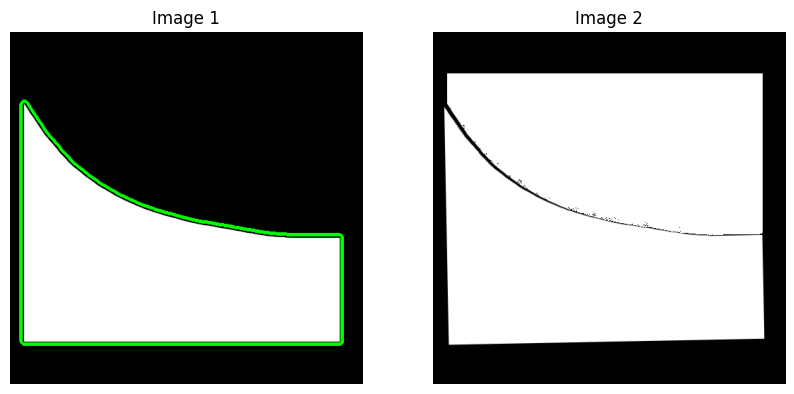

In [198]:
fig, ax = plt.subplots(1, 2, figsize=(10, 10))

# Left image
ax[0].imshow(cv2.cvtColor(output1, cv2.COLOR_BGR2RGB))
ax[0].set_title("Image 1")
ax[0].axis("off")

# Right image (YOU WERE MISSING THIS)
print(np.array(aligned).shape)
ax[1].imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
ax[1].set_title("Image 2")
ax[1].axis("off")
plt.show()
